# Laboratorio 3 - SmartAlpes

## Integrantes

- Isabella Naranjo
- David Caro

## Exploración de los datos

### Carga de datos

Verificamos que los datos se cargaron correctamente y analizamos su estructura.

In [2]:
import pandas as pd

df = pd.read_csv('../data/Datos_Laboratorio3.csv', delimiter=';', encoding='latin-1')
print("Verificamos que los datos cargaron correctamente: ")
pd.set_option('display.max_columns', None) 
print(df.head())
print('\n')
print(df.tail())
print('\nDimensiones del DataFrame: ')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Total de celdas: {df.size}")

Verificamos que los datos cargaron correctamente: 
   Edad     Gnereo   Peso  Altura    BMI     Objetivo     Condicion_salud  \
0    60  Masculino   73.7    1.61  28.43  Resistencia        Hipertension   
1    17   Femenino  121.0    1.97  31.18  Resistencia  Enfermedad corazon   
2    43  Masculino  110.0    1.52  47.61      General             Ninguno   
3    49       Otro   73.6    1.96  19.16      General             Ninguno   
4    53   Femenino   80.8    1.76  26.08  Resistencia        Hipertension   

  Nivel_Actividad Nivel_experiencia Dieta_preferida  Horas_sueño  \
0            Bajo          Avanzado          Vegano          5.5   
1        Moderado      Principiante     Vegetariano          6.9   
2            Bajo      Principiante  No-Vegetariano          6.0   
3        Moderado      Principiante  No-Vegetariano          5.7   
4            Alto      Principiante    Pescetariano          5.8   

  Entrenamiento_preferido  Cantidad_equipo  Tiempo_disponible  Tiene_alergia 

Verificamos que el tipo de variable del diccionario coincida con el tipo de variable de los datos en el dataset, y realizamos un primer acercamiento respecto a los valores nulos presentes en cada variable.

In [3]:
df.info()
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f'Variables númericas: {len(variables_numericas)}')
print(f'Variables categoricas: {len(variables_categoricas)}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Gnereo                   9698 non-null   object 
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   object 
 6   Condicion_salud          9698 non-null   object 
 7   Nivel_Actividad          9698 non-null   object 
 8   Nivel_experiencia        9698 non-null   object 
 9   Dieta_preferida          9698 non-null   object 
 10  Horas_sueño              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   object 
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible        9698 non-null   int64  
 14  Tiene_alergia           

Realizamos un primer acercamiento a la exploración de outliers y valores imposibles en las variables númericas.

In [4]:
df.describe()

,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


Exploramos problemas de calidad relacionados con las variables categoricas.

In [ ]:
for col in variables_categoricas:
    print("\n")
    print(df[col].value_counts())



Gnereo
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64


Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64


Condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64


Nivel_Actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64


Nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64


Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64


Entrenamiento_preferido
Funcional       1666
Hit             1620
Flexibilidad    1618
Cardio          1602
Fuerza          1601
Balance         1

Realizamos la exploración de nulos, duplicados (completos, lógicos e inconsistencias) y outliers de las variables númericas.

In [23]:
# Exploración de nulos

valores_nulos_por_categoria = df.isnull().sum()
porcentaje_nulos_por_categoria = ((valores_nulos_por_categoria / len(df)) * 100).round(2)

nulos = pd.DataFrame({
    "Nulos": valores_nulos_por_categoria,
    "Porcentaje (%)": porcentaje_nulos_por_categoria
})

print(nulos[nulos['Nulos'] > 0])

# Exploración de duplicados identicos 

duplicados_identicos = df.duplicated().sum()
print(f"\nDuplicados identicos: {duplicados_identicos}")

# Exploración de inconsistencias

# ¿Hay cigarrillos registrados en personas que dicen no fumar?
mask = (df['Cigarrillos_dia'] > 0) & (df['Fumador'] == 0)
print(f"\nCigarrillos sin ser fumador: {mask.sum()}")

# ¿Hay consumo de alcohol en personas que dicen no beber?
mask2 = (df['Alcohol_semana'] > 0) & (df['Alcohol'] == 0)
print(f"Alcohol_semana sin ser bebedor: {mask2.sum()}")

# Outliers 

for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"\n{col}: {len(outliers)} outliers estadísticos | min={df[col].min()} max={df[col].max()}")

      Nulos  Porcentaje (%)
Peso     11            0.11

Duplicados identicos: 0

Cigarrillos sin ser fumador: 0
Alcohol_semana sin ser bebedor: 0

Edad: 0 outliers estadísticos | min=15 max=75

Peso: 0 outliers estadísticos | min=45.0 max=140.0

Altura: 0 outliers estadísticos | min=1.5 max=2.05

BMI: 12 outliers estadísticos | min=10.93 max=62.09

Horas_sueño: 4 outliers estadísticos | min=0.0 max=23.0

Cantidad_equipo: 0 outliers estadísticos | min=0 max=6

Tiempo_disponible: 0 outliers estadísticos | min=15 max=120

Tiene_alergia: 1955 outliers estadísticos | min=0 max=1

Problemas_digestivos: 1492 outliers estadísticos | min=0 max=1

Fumador: 2205 outliers estadísticos | min=0 max=1

Cigarrillos_dia: 2205 outliers estadísticos | min=0.0 max=18.0

Alcohol: 0 outliers estadísticos | min=0 max=1

Alcohol_semana: 1695 outliers estadísticos | min=0.0 max=25.0

Score_micronutrientes: 0 outliers estadísticos | min=0.0 max=1.0

Ingesta_proteinas: 0 outliers estadísticos | min=40.0 max=220

Exploramos valores sospechosos que son candidatos a ser imposibles de las diferentes variables según rangos razonables.

In [ ]:
rangos = {
    'Edad':               (15, 75),
    'Peso':               (30, 200),
    'Altura':             (1.40, 2.20),
    'BMI':                (10, 60),
    'Horas_sueño':        (3, 14),
    'Ingesta_proteinas':  (20, 300),
    'Pasos_dia':          (0, 50000),
    'Ingesta_agua':       (0.5, 6),
    'Score_micronutrientes': (0, 1),
    'Cigarrillos_dia':    (0, 20),
    'Alcohol_semana':     (0, 50),
    'Tiempo_disponible':  (15, 120),
    'Cantidad_equipo':    (0, 6),
}

print('Valores Sospechosos: ')

for col, (minimo, maximo) in rangos.items():
    fuera = df[(df[col] < minimo) | (df[col] > maximo)]
    if len(fuera) > 0:
        print(f"{col}: {len(fuera)} valores fuera del rango [{minimo}, {maximo}]")
        print(fuera[[col]].to_string())
        print()
        
df['BMI_calculado'] = df['Peso'] / (df['Altura'] ** 2)
df['BMI_diferencia'] = abs(df['BMI'] - df['BMI_calculado'])

print('Exploración de valores sospechosos del BMI: ')
sospechosos = df[df['BMI'] > 60][['Peso', 'Altura', 'BMI', 'BMI_calculado', 'BMI_diferencia']]
print(sospechosos.round({'Peso': 1, 'Altura': 2, 'BMI': 2, 'BMI_calculado': 2, 'BMI_diferencia': 4}).to_string())
df.drop(columns=['BMI_calculado', 'BMI_diferencia'], inplace=True)

Valores Sospechosos: 
BMI: 16 valores fuera del rango [10, 60]
        BMI
221   60.22
1701  61.02
2531  60.80
2884  60.12
2891  60.47
2975  60.38
2997  61.78
3653  60.17
4369  60.70
5512  62.09
5728  61.09
6843  60.74
7411  60.26
7978  60.96
7995  60.57
9380  60.03

Horas_sueño: 3 valores fuera del rango [3, 14]
      Horas_sueño
2250         23.0
2627          0.0
9504         15.0

Exploración de valores sospechosos del BMI: 
       Peso  Altura    BMI  BMI_calculado  BMI_diferencia
221   137.3    1.51  60.22          60.22          0.0033
1701  137.3    1.50  61.02          61.02          0.0022
2531  136.8    1.50  60.80          60.80          0.0000
2884  138.9    1.52  60.12          60.12          0.0005
2891  139.7    1.52  60.47          60.47          0.0043
2975  139.5    1.52  60.38          60.38          0.0008
2997  139.0    1.50  61.78          61.78          0.0022
3653  137.2    1.51  60.17          60.17          0.0028
4369  138.4    1.51  60.70          60.70    

En este caso tenemos 2 variables objetivo: **Plan de Entrenamiento** y **Plan de nutrición**. Realizamos 2 gráficas para poder ver la distribución de estas 2 variables objetivo e identificar si se evidencia un desbalance de clases.

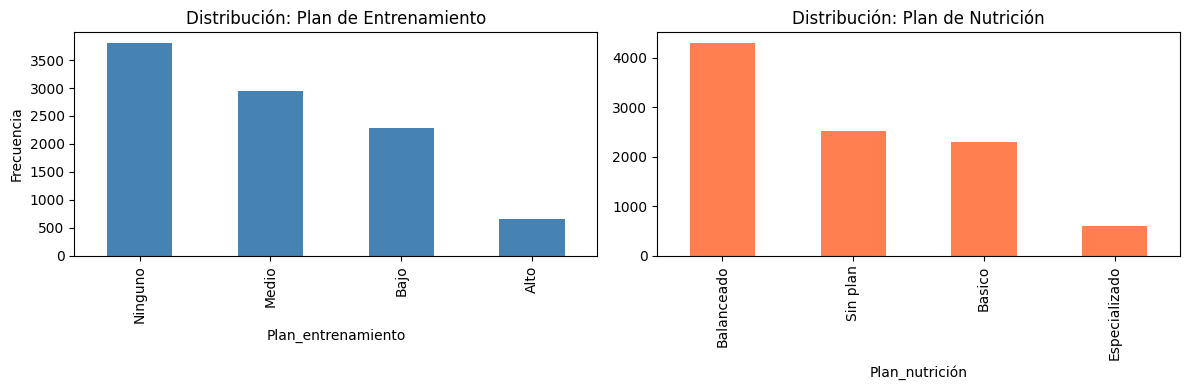

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Plan_entrenamiento'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución: Plan de Entrenamiento')
axes[0].set_ylabel('Frecuencia')

df['Plan_nutrición'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribución: Plan de Nutrición')

plt.tight_layout()
plt.show()

Realizamos una matriz de correlación entre las variables númericas para poder evidenciar redundancia entre las variables.

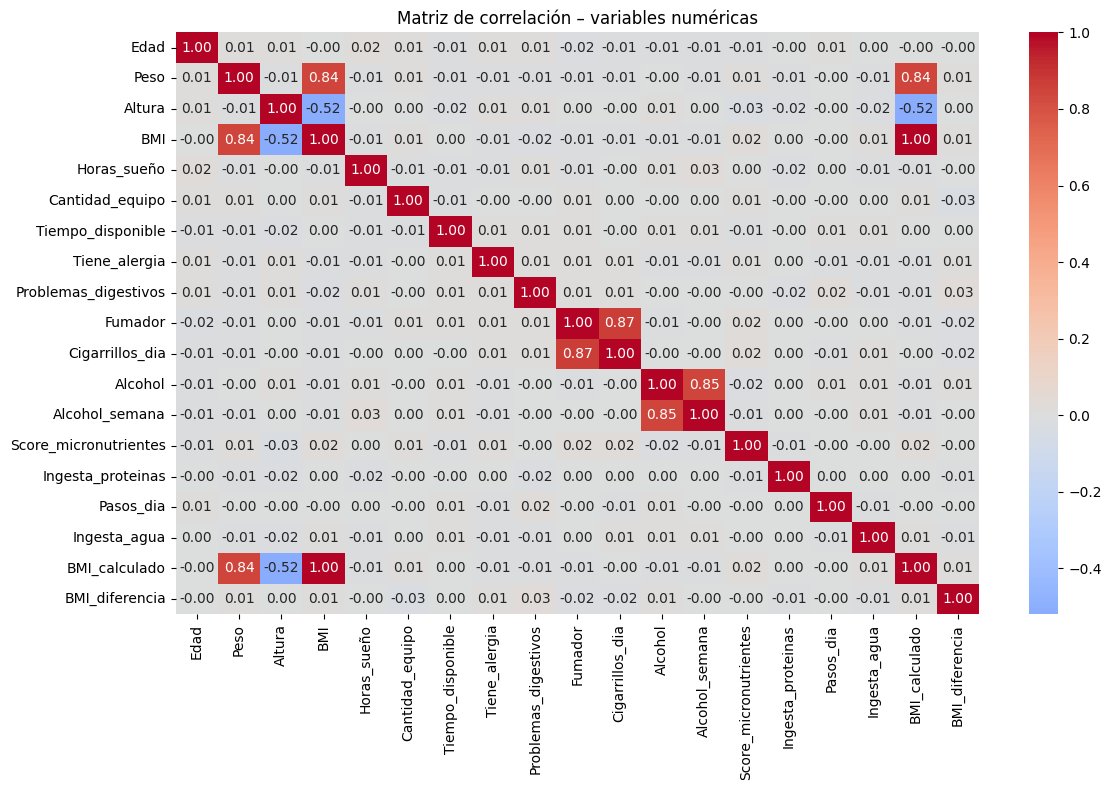

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr().round(2),
            annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
plt.show()

### Hallazgos de la exploración de los datos